# Recovery hotspot design

Identify engineered codon mutations from the CGG naive scFv that simultaneously:
1. **Strongly reduce affinity** (`delta_bind_CGG ≤ -2`)
2. **Create a hotspot for recovery** under the S5F model: the mutant sequence context has high mutability and strong substitution preference toward a nucleotide that restores a nearly-affinity-preserving amino acid (`delta_bind_CGG ≥ -0.1`)

The engineered codon can differ from naive by any number of nucleotides. Additionally, synonymous changes in the flanking codons (positions ±1–2 nt from the focal codon boundary) are enumerated to optimize the 5-mer context at the recovery position.

**Recovery score** = S5F_mutability(mutant 5-mer at recovery position) × S5F_substitution_prob(→ recovery nt)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio.Seq import Seq

In [32]:
import sys
sys.path.insert(0, "..")
from passenger.passenger import CHIGY_HC_STOP_TRIMMED, CHIGY_LC_STOP_TRIMMED

# S5F model tables
s5f_mut = pd.read_csv(
    "../data/mutability/MK_RS5NF_mutability.csv",
    sep=r"\s+", index_col=0,
)
s5f_subst = pd.read_csv(
    "../data/mutability/MK_RS5NF_substitution.csv",
    sep=r"\s+", index_col=0,
)

# DMS effects from mutations table
mutations_csv = "../results/notebooks/mutations/naive_reversions_first/data.csv"
muts_df = (
    pd.read_csv(mutations_csv)
    .query("single_nt == True and mutant != wildtype and mutant != '*'")
    .dropna(subset=["delta_bind_CGG", "delta_expr"])
)

# Build lookup: (chain, position, mutant_aa) -> {mutation, delta_bind_CGG, delta_expr}
# HC positions are 1-based within HC (1-112); LC positions are scFv positions (128-235)
# 'mutation' column uses IMGT positions (canonical name)
dms_lookup = (
    muts_df
    .set_index(["chain", "position", "mutant"])[["mutation", "delta_bind_CGG", "delta_expr"]]
    .to_dict("index")
)

print(f"S5F mutability table: {len(s5f_mut)} fivemers")
print(f"HC naive: {len(CHIGY_HC_STOP_TRIMMED)} nt")
print(f"LC naive: {len(CHIGY_LC_STOP_TRIMMED)} nt")
print(f"DMS lookup entries: {len(dms_lookup)}")

S5F mutability table: 2500 fivemers
HC naive: 337 nt
LC naive: 322 nt
DMS lookup entries: 1281


In [33]:
from itertools import product

def fivemers(seq):
    """Return list of 5-mers (NN-padded) centered at each position in seq."""
    padded = "NN" + seq + "NN"
    return [padded[i : i + 5] for i in range(len(seq))]


# Codon table: AA -> list of codons
CODON_TABLE = {}
for _a, _b, _c in product("ACGT", repeat=3):
    _codon = _a + _b + _c
    _aa = str(Seq(_codon).translate())
    CODON_TABLE.setdefault(_aa, []).append(_codon)


RECOVERY_THRESHOLD = -0.1


def enumerate_candidates(naive_seq, chain, lc_offset=0):
    """
    For each codon position and each damaging AA (with DMS data), enumerate:
      - all codons encoding the target AA (focal codon)
      - synonymous variants at flanking positions (prev codon pos 1,2; next codon pos 0,1)
    and find the best single-nt recovery mutation in the focal codon that restores
    an AA with delta_bind_CGG >= RECOVERY_THRESHOLD.

    Returns one row per (codon_idx, target_aa): the combination with the best recovery rate.
    """
    n_complete = (len(naive_seq) // 3) * 3
    n_codons = n_complete // 3

    # Track best per (codon_idx, alt_aa)
    best_by_mutation = {}

    for codon_idx in range(n_codons):
        codon_start = codon_idx * 3
        naive_codon = naive_seq[codon_start : codon_start + 3]
        naive_aa = str(Seq(naive_codon).translate())
        dms_pos = codon_idx + 1 + lc_offset

        # Synonymous variants for preceding codon (vary positions 1,2; fix position 0)
        has_prev = codon_idx > 0
        if has_prev:
            prev_start = (codon_idx - 1) * 3
            prev_naive = naive_seq[prev_start : prev_start + 3]
            prev_aa = str(Seq(prev_naive).translate())
            prev_variants = [c for c in CODON_TABLE[prev_aa] if c[0] == prev_naive[0]]
        else:
            prev_variants = [None]

        # Synonymous variants for following codon (vary positions 0,1; fix position 2)
        has_next = codon_idx < n_codons - 1
        if has_next:
            next_start = (codon_idx + 1) * 3
            next_naive = naive_seq[next_start : next_start + 3]
            next_aa = str(Seq(next_naive).translate())
            next_variants = [c for c in CODON_TABLE[next_aa] if c[2] == next_naive[2]]
        else:
            next_variants = [None]

        for alt_aa in CODON_TABLE:
            if alt_aa == naive_aa or alt_aa == "*":
                continue
            key = (chain, dms_pos, alt_aa)
            if key not in dms_lookup:
                continue
            delta = dms_lookup[key]

            for focal_codon in CODON_TABLE[alt_aa]:
                for prev_var in prev_variants:
                    for next_var in next_variants:
                        # Build mutant sequence
                        mut_seq = list(naive_seq)
                        mut_seq[codon_start : codon_start + 3] = list(focal_codon)
                        if prev_var is not None:
                            mut_seq[prev_start + 1] = prev_var[1]
                            mut_seq[prev_start + 2] = prev_var[2]
                        if next_var is not None:
                            mut_seq[next_start] = next_var[0]
                            mut_seq[next_start + 1] = next_var[1]
                        mut_seq_str = "".join(mut_seq)

                        n_nt_changes = sum(
                            1 for k in range(len(naive_seq)) if naive_seq[k] != mut_seq_str[k]
                        )
                        if n_nt_changes == 0:
                            continue

                        mut_fmers = fivemers(mut_seq_str)

                        # Find best recovery in the focal codon
                        for cp in range(3):
                            rec_pos = codon_start + cp
                            cur_nt = mut_seq_str[rec_pos]
                            for rec_nt in "ACGT":
                                if rec_nt == cur_nt:
                                    continue
                                rec_codon = focal_codon[:cp] + rec_nt + focal_codon[cp + 1 :]
                                rec_aa = str(Seq(rec_codon).translate())
                                if rec_aa == "*" or rec_aa == alt_aa:
                                    continue

                                if rec_aa == naive_aa:
                                    rec_bind = 0.0
                                else:
                                    rec_key = (chain, dms_pos, rec_aa)
                                    if rec_key not in dms_lookup:
                                        continue
                                    rec_bind = dms_lookup[rec_key]["delta_bind_CGG"]

                                if rec_bind < RECOVERY_THRESHOLD:
                                    continue

                                rec_fmer = mut_fmers[rec_pos]
                                if rec_fmer not in s5f_mut.index:
                                    continue
                                rate = (
                                    s5f_mut.loc[rec_fmer, "Mutability"]
                                    * s5f_subst.loc[rec_fmer, rec_nt]
                                )

                                mut_key = (codon_idx, alt_aa)
                                if mut_key not in best_by_mutation or rate > best_by_mutation[mut_key]["recovery_rate_s5f"]:
                                    # Describe nt changes
                                    changes = []
                                    for k in range(len(naive_seq)):
                                        if naive_seq[k] != mut_seq_str[k]:
                                            changes.append(f"{naive_seq[k]}{k}{mut_seq_str[k]}")

                                    best_by_mutation[mut_key] = {
                                        "mutation": delta["mutation"],
                                        "chain": chain,
                                        "codon_idx": codon_idx,
                                        "codon_start": codon_start,
                                        "naive_codon": naive_codon,
                                        "engineered_codon": focal_codon,
                                        "naive_aa": naive_aa,
                                        "mutant_aa": alt_aa,
                                        "n_nt_changes": n_nt_changes,
                                        "nt_changes": ", ".join(changes),
                                        "delta_bind_CGG": delta["delta_bind_CGG"],
                                        "delta_expr": delta["delta_expr"],
                                        "recovery_codon_pos": cp,
                                        "recovery_nt_pos": rec_pos,
                                        "recovery_nt": rec_nt,
                                        "recovery_aa": rec_aa,
                                        "recovery_bind": rec_bind,
                                        "recovery_fivemer": rec_fmer,
                                        "recovery_rate_s5f": rate,
                                    }

    return pd.DataFrame(list(best_by_mutation.values()))


hc_df = enumerate_candidates(CHIGY_HC_STOP_TRIMMED, chain="H", lc_offset=0)
lc_df = enumerate_candidates(CHIGY_LC_STOP_TRIMMED, chain="L", lc_offset=127)
all_df = pd.concat([hc_df, lc_df], ignore_index=True)

print(f"HC: {len(hc_df)} (codon, target_aa) pairs with recovery path")
print(f"LC: {len(lc_df)} (codon, target_aa) pairs with recovery path")
print(f"Total: {len(all_df)}")

HC: 653 (codon, target_aa) pairs with recovery path
LC: 622 (codon, target_aa) pairs with recovery path
Total: 1275


In [34]:
# Filter to strong affinity reduction
candidates = (
    all_df
    .query("delta_bind_CGG <= -1")
    .sort_values("recovery_rate_s5f", ascending=False)
    .reset_index(drop=True)
)

print(f"{len(candidates)} mutations with delta_bind_CGG ≤ -1\n")

display_cols = [
    "mutation", "delta_bind_CGG", "delta_expr",
    "naive_codon", "engineered_codon", "n_nt_changes", "nt_changes",
    "recovery_aa", "recovery_bind", "recovery_fivemer", "recovery_nt",
    "recovery_rate_s5f",
]
with pd.option_context("display.float_format", "{:.4f}".format, "display.max_colwidth", 30):
    print(candidates[display_cols].head(30).to_string(index=True))

candidates[display_cols].to_csv("output/reversion-hotspot/candidates.csv", index=False)

109 mutations with delta_bind_CGG ≤ -1

    mutation  delta_bind_CGG  delta_expr naive_codon engineered_codon  n_nt_changes                         nt_changes recovery_aa  recovery_bind recovery_fivemer recovery_nt  recovery_rate_s5f
0    I91(L)S         -1.3391     -1.8139         ATC              AGT             5  C221G, T223G, C224T, A225T, G226C           N        -0.0399            GAGTT           A             0.0076
1    Y38(H)C         -1.5332     -0.3160         TAC              TGT             3                   T95G, A97G, C98T           Y         0.0000            GTGTT           A             0.0057
2    Y87(H)C         -1.2733     -0.1034         TAC              TGT             2                       A232G, C233T           Y         0.0000            GTGTT           A             0.0057
3   Y102(L)C         -1.3537     -1.7047         TAT              TGT             1                              A256G           Y         0.0000            GTGTT           A          

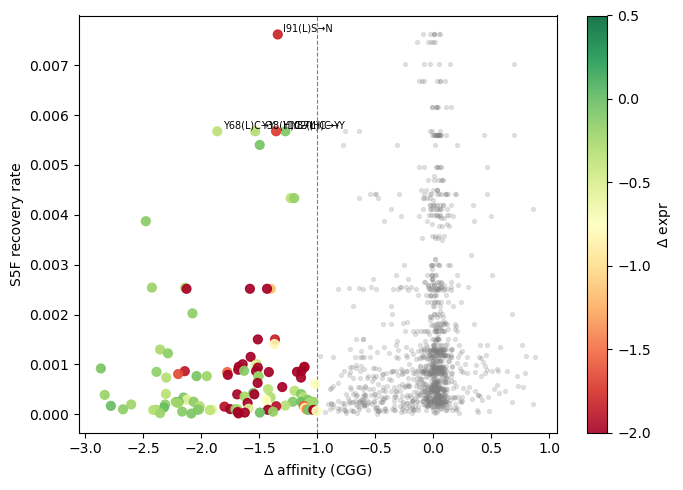

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))

# All mutations with recovery paths
ax.scatter(
    all_df["delta_bind_CGG"], all_df["recovery_rate_s5f"],
    alpha=0.2, s=8, color="grey", label="all mutations",
)

# Strong affinity reduction candidates, colored by delta_expr
sc = ax.scatter(
    candidates["delta_bind_CGG"], candidates["recovery_rate_s5f"],
    c=candidates["delta_expr"], cmap="RdYlGn", vmin=-2, vmax=0.5,
    alpha=0.9, s=40, zorder=3,
)
plt.colorbar(sc, ax=ax, label=r"$\Delta$ expr")

# Annotate top candidates by recovery score
top_n = 5
for _, row in candidates.head(top_n).iterrows():
    ax.annotate(
        f"{row['mutation']}→{row['recovery_aa']}",
        (row["delta_bind_CGG"], row["recovery_rate_s5f"]),
        textcoords="offset points", xytext=(4, 2),
        fontsize=7,
    )

ax.axvline(-1, color="k", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel(r"$\Delta$ affinity (CGG)")
ax.set_ylabel("S5F recovery rate")
plt.tight_layout()
plt.savefig("output/reversion-hotspot/affinity_vs_recovery.pdf", bbox_inches="tight")
plt.show()

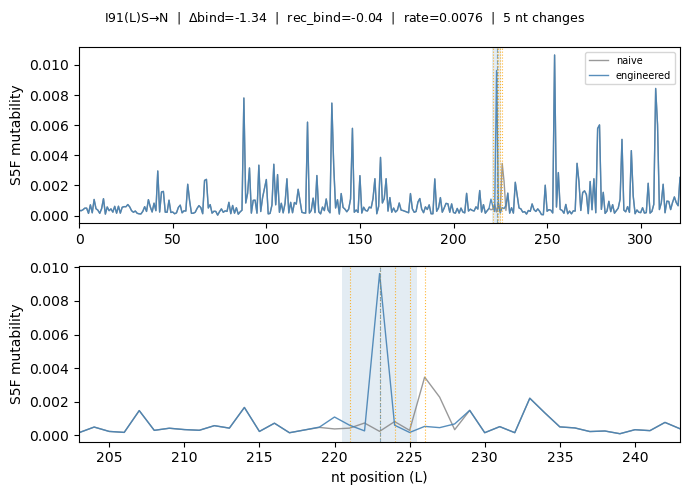

In [36]:
def seq_mutability(seq):
    return np.array([
        s5f_mut.loc[f, "Mutability"] if f in s5f_mut.index else np.nan
        for f in fivemers(seq)
    ])


naive_mut = {
    "H": seq_mutability(CHIGY_HC_STOP_TRIMMED),
    "L": seq_mutability(CHIGY_LC_STOP_TRIMMED),
}

row = candidates.iloc[0]
chain = row["chain"]
naive_seq = CHIGY_HC_STOP_TRIMMED if chain == "H" else CHIGY_LC_STOP_TRIMMED
rec_nt_pos = int(row["recovery_nt_pos"])

# Rebuild engineered mutant sequence
mutant_seq = list(naive_seq)
for change in row["nt_changes"].split(", "):
    pos = int(change[1:-1])
    mutant_seq[pos] = change[-1]
mutant_seq = "".join(mutant_seq)
mutant_m = seq_mutability(mutant_seq)
naive_m = naive_mut[chain]

change_positions = [int(c[1:-1]) for c in row["nt_changes"].split(", ")]

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharey=False)

window = 20
views = [
    (0, len(naive_m)),
    (max(0, rec_nt_pos - window), min(len(naive_m), rec_nt_pos + window + 1)),
]

for ax, (lo, hi) in zip(axes, views):
    xz = np.arange(lo, hi)
    ax.plot(xz, naive_m[lo:hi], color="grey", lw=1, alpha=0.8, label="naive")
    ax.plot(xz, mutant_m[lo:hi], color="steelblue", lw=1, alpha=0.9, label="engineered")

    for cpos in change_positions:
        if lo <= cpos < hi:
            ax.axvline(cpos, color="orange", lw=0.8, ls=":", alpha=0.8)

    ax.axvspan(
        max(lo, rec_nt_pos - 2.5), min(hi, rec_nt_pos + 2.5),
        color="steelblue", alpha=0.15, lw=0,
    )
    ax.axvline(rec_nt_pos, color="steelblue", lw=0.8, ls="--", alpha=0.6)

    ax.set_xlim(lo, hi - 1)
    ax.set_ylabel("S5F mutability")

axes[0].legend(fontsize=7)
axes[1].set_xlabel(f"nt position ({chain})")
fig.suptitle(
    f"{row['mutation']}→{row['recovery_aa']}  |  "
    f"$\\Delta$bind={row['delta_bind_CGG']:.2f}  |  "
    f"rec_bind={row['recovery_bind']:.2f}  |  "
    f"rate={row['recovery_rate_s5f']:.4f}  |  "
    f"{row['n_nt_changes']} nt changes",
    fontsize=9,
)
plt.tight_layout()
plt.savefig("output/reversion-hotspot/mutability_profile.pdf", bbox_inches="tight")
plt.show()